#  0. Setting Definitions, Objective 1a (direction $N \to G$)


## 0.1 - Notation
$(N, \sigma)$ is a **leaf-coloured phylogenetic network**: a directed acyclic graph with a unique root $\rho$, no vertex of in-degree 1 and out-degree 1, leaf set $L$ (vertices of out-degree 0, representing genes) and a surjective colouring $\sigma: L \to S$ assigning each gene to its species. Vertices with in-degree $\geq 2$ are hybridization vertices, if there are none $(N,\sigma)$ is a leaf-coloured tree $(T,\sigma)$

### Ancestor order
For $u,v \in V(N)$ write $u \preceq v$ if there is a directed path from $v$ to $u$, including the empty path, so $u \preceq u$ - $u$ is ancestor of itself (reflexivity).
$u \prec v$ if $u \preceq v$ and $u \neq v$. Hence $\preceq$ is a partial order with $\rho$ as its unique maximum and $L$ as its set of minimal elements. On a tree, all ancestors of a leaf $x$ lie on its unique root path and are therefore totally ordered. On a network $x$ may have several root paths and two of its ancestors may be **incomparable**.

### Last common ancestor
For $x,y \in L$, a *common ancestor* is a vertex $v$ from which both $x$ and $y$ are reachable, $x \preceq v$ and $y \preceq v$. The set of common ancestors is non-empty (has to contain $\rho$) and closed upwards: every ancestor of a common ancestor is again a common ancestor. Most of then are uninteresting - we only care about the lowest ones. The $min_{\preceq}$ removes every vertex that has another vertex of the same set strictly beneath it, so
$$LCA(x,y):= min_{\preceq}\{v \in V(N): x \preceq v \text{ and } y \preceq v \}$$

is the set of common ancestors that no other common ancestor undercuts. By construction $LCA(x,y)\neq \emptyset$ and its elements are pairwise incomparable. On a tree there is only one route and LCA(x,y) collapses to the singleton set $\{lca(x,y)\}$.
### Lowest meeting point with a colour
Now fix $x$ and a species $\tau \neq \sigma(x)$. For each gene $y$ of species $\tau$, LCA(x,y) is the set of lowest vertices from which you can reach both $x$ and $y$. Now throw all those sets together over every $y$ of colour $\tau$:
$$U = LCA(x,y_1)\cup LCA(x,y_2) \cup ...$$
and again keep only the lowest ones:
$$Q(x,\tau) := min_{\preceq}U(x,\tau)$$
A vertex of $U$ survives into $Q$ iff no meeting point of $x$ with *any* gene of colour $\tau$ lies strictly beneath it.

### Best match graphs
A leaf-coloured digraph $(G,\sigma)$ has a vertex set $V(G)=L$ and inherits the colouring $\sigma$. Given $(N, \sigma)$ and a notion of best match (Section 0.2), the associated best match graph $G(N,\sigma)$ has an arc $(x,y)$ iff $y$ is a best match of $x$. We write $N^+_G(x)$ and $N^-_G(x)$ for out- and in-neighbourhoods in $G$.

## 0.2 Definitions
We fix $(N,\sigma)$ and $x,y\in L$ with $\sigma(x) \neq \sigma(y)$ and write $\tau := \sigma(y)$.

### Def. 0 (best matches on a tree - Geiß et al. 2019, Def.1)
Let $(T,\sigma)$ be a leaf-coloured tree and $x,y\in L$ with $\sigma(x)\neq\sigma(y)$. Then $y$ is a *best match* of $x$, written as $x \to y$, if
$$lca(x,y) \preceq lca(x,y') \text{ for all } y' \in L \text{ with } \sigma(y')=\sigma(y)$$
Ties are allowed, so $x$ may have several best matches of the same colour. Also the relationship is not symmetric, $x \to y \not\implies y \to x$

### Why this does not transfer to networks
Definition 0 uses two facts that hold on trees but not on networks: $lca(x,y)$ is a single vertex and all $lca(x,*)$ lie on a unique root path to $x$, so any two of them are comparable. On a network $LCA(x,y)$ is a set and for two leaves $y,y'$ of the same colour of sets $LCA(x,y)$ and $LCA(x,y')$ may contain pairwise incomparable elements. The inequality $lca(x,y)\preceq lca(x,y')$ therefore has no direct meaning and one must decide how to compare *sets* of meeting points, theres two possible choices:

#### Definition 1 (strict best match):
Fix $y$ and a competitor $y'$ of the same colour. Compare every $u \in LCA(x,y')$ with every $v\in LCA(x,y)$. Each such pair is in exactly one of three relations:
* $u \prec v$: the competitor meets $x$ strictly below a meeting point of $y$ - not allowed
* $v \preceq u$ $y$ meets $x$ at or below the competitors meeting point - allowed
* $u$ and $v$ incomparable - allowed

$y$ is a strict best match of $x$ iff, the first case doesn't hold true -  no member of Lca(x,y') is strictly lower than any member of Lca(x,y).

#### Definition 2 (weak best match):
$y$ is a weak best match of $x$ if at least one of the meeting points of $x$ and $y$ is an unbeaten meeting point of $x$ with species $\sigma(y)$:
$$LCA(x,y)\cap Q(x, \sigma(y))\neq \emptyset$$

OR

Fix $y$ and a competitor $y'$ of the same colour. Compare every $u \in LCA(x,y')$ with every $v\in LCA(x,y)$. Each such pair is in exactly one of four relations:
* $v \prec u$: $y$ meets $x$ below the competitor - allowed
* $v = u$: the meeting point is the same - allowed
* they are incomparable - allowed
* $u \prec v$: competitor meets $x$ below $y$ - not allowed

$y$ is a weak best match of $x$ if at least one member of lca(x,y) is not strictly above any member of lca(x,y')

# 0.3 Formal argument (Objective 1a)
To recap:
$$\text{strict: } \neg \exists u \in LCA(x,y), \exists v \in Q(x,\tau): v \prec u$$
$$\text{weak: } \neg \forall u \in LCA(x,y), \exists v \in Q(x,\tau): v \prec u$$
Or:
$$\text{strict: } \forall u \in LCA(x,y): \neg \exists v \in Q(x,\tau): v \prec u$$
$$\text{weak: } \exists u \in LCA(x,y): \neg \exists v \in Q(x,\tau): v \prec u$$

With
$$D := LCA(x,y)$$
And
$$P:= \neg \exists v \in Q(x,\tau): v \prec u$$

## Lemma 1 (all implies some)
$$\forall u \in D: P \implies \exists u \in D: P$$

Let $D$ e a set and let $P$ be a statement about elements $u \in D$. If $D$ is non-empty and $P$ holds for every $u\in D$, then $P$ holds for at least one $u \in D$.

### Proof 1
Because $D$ is non-empty, we can pick an element and call it $u_0$. Because $P$ holds for every element of $D$ it holds in particular for $u_0$. So there is an element of $D$ for which $P$ holds. $\square$

## Lemma 2 (meeting point exists)
For any two leaves $x,y\in L$, the set $LCA(x,y)$ is non-empty.

### Proof 2
The root $\rho$ lies above every vertex and is a common ancestor to any $x$ and $y$. The set of common ancestor can therefore only be non-empty. $\square$

### Proof 3
Strict says $P$ holds for every $u \in D$, weak says $P$ holds for at least one $u\in D$. By Lemma 2 $LCA(x,y) \neq \emptyset$, so Lemma 1 applies, hence strict implies weak. $\square$

# 0.4/0.5 Testing computationally

![BMG.png](rendered_pseudocode/BMG.png)

In [7]:
import sys
sys.path.insert(0, "../../")
import networkx as nx
import matplotlib.pyplot as plt
from networkx.drawing.nx_pydot import graphviz_layout
from bmg_Tony import bmg

In [8]:
# creating the bic Cherry from the networks paper, figure 2 b
bic_cherry = nx.DiGraph()
bic_cherry.add_nodes_from([("y", {"color": "red"}), ("x", {"color": "blue"}), ("z", {"color": "red"})])
bic_cherry.add_edges_from([("rho", "Pxy"), ("Pxy", "y"), ("Pxy", "x"), ("Pxy", "Qxz"), ("Qxz", "x"), ("Qxz", "z"),
                           ("rho", "Pxz"), ("Pxz", "z"), ("Pxz", "x"), ("Pxz", "Qxy"), ("Qxy", "x"), ("Qxy", "y")])

Text(0.5, 1.0, 'Weak BMG')

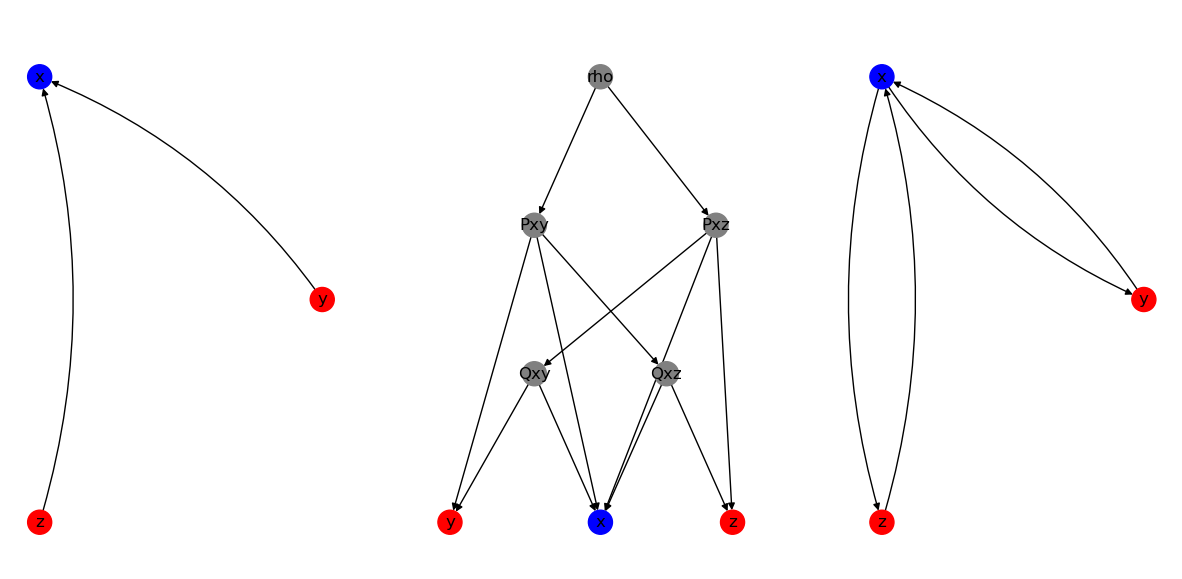

In [27]:
# figure with three subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 7))
pos = graphviz_layout(bic_cherry, prog="dot")
nodes_list, nodes_colors = zip(*bic_cherry.nodes(data="color", default="grey"))
nx.draw(bic_cherry, pos, nodelist=nodes_list, node_color= nodes_colors, ax=axes[1], with_labels = True)
axes[1].set_title("Network")

# strong bmg
strong_bmg = bmg(bic_cherry, mode="strong")
pos = nx.circular_layout(strong_bmg)
nodes_list, nodes_colors = zip(*strong_bmg.nodes(data="color", default="grey"))
nx.draw(strong_bmg, pos, nodelist=nodes_list, node_color= nodes_colors, ax=axes[0], with_labels=True,connectionstyle="arc3,rad=0.15")
axes[0].set_title("Strikt BMG")

# weak BMG
weak_bmg = bmg(bic_cherry, mode="weak")
nx.draw(weak_bmg, pos, nodelist=nodes_list, node_color= nodes_colors, ax=axes[2], with_labels=True,connectionstyle="arc3,rad=0.15")
axes[2].set_title("Weak BMG")

In [15]:
import sys, random
sys.path.insert(0, "../../")
import numpy as np, pandas as pd
from tqdm.auto import tqdm
from asymmetree.treeevolve import species_tree_n, dated_gene_tree, prune_losses
from bmg_Tony import bmg
from insert_hybrid import insertHybrid
from bmg_fun import convert_to_nx


def random_network(n_species, dupl_rate, loss_rate, n_hybrid, seed, max_leaves=40):
    random.seed(seed)                                   # insertHybrid uses global random
    S = species_tree_n(n_species)
    T = prune_losses(dated_gene_tree(S, dupl_rate=dupl_rate, loss_rate=loss_rate))  # observable tree
    N = convert_to_nx(T)
    leaves = [v for v in N if N.out_degree(v) == 0]
    assert all(N.nodes[v].get("event") != "L" for v in leaves), "loss leaf survived pruning"
    if not 3 <= len(leaves) <= max_leaves:              # skip trivial and runaway trees
        return None
    return insertHybrid(N, i=n_hybrid)


rng = random.Random(0)
rows = []
for _ in tqdm(range(20000)):
    p = dict(n_species=rng.randint(2, 8),
             dupl_rate=round(rng.uniform(0.2, 1.0), 2),
             loss_rate=round(rng.uniform(0.2, 1.0), 2),
             n_hybrid=rng.randint(0, 10),
             seed=rng.randrange(2**32))
    N = random_network(**p)
    if N is None:
        continue

    leaves = [v for v in N if N.out_degree(v) == 0]
    n_colors = len({N.nodes[v]["color"] for v in leaves})
    assert n_colors <= p["n_species"], "more colours than species"

    Gs = set(bmg(N, "strong").edges())
    Gw = set(bmg(N, "weak").edges())

    rows.append(dict(
        **p,
        n_leaves=len(leaves),
        n_colors=n_colors,
        n_hyb_inserted=sum(1 for v in N if N.nodes[v].get("event") == "H"),
        n_retic=sum(1 for v in N if N.in_degree(v) >= 2),
        inclusion=Gs <= Gw,
        differ=Gs != Gw,
        n_strict=len(Gs),
        n_weak=len(Gw),
        n_strict_in_weak=len(Gs & Gw),                  # numerator of both conditionals
        n_weak_only=len(Gw - Gs),
        n_leaves_affected=len({x for x, _ in Gw - Gs}), # leaves with a weak-only out-arc
    ))

df = pd.DataFrame(rows)
df.to_csv("obj1a_validation.csv", index=False)

print(f"{len(df)} networks; inclusion holds in {df.inclusion.mean():.1%} "
      f"({df.n_strict_in_weak.sum()} of {df.n_strict.sum()} strict arcs found in the weak BMG); "
      f"definitions differ in {df.differ.mean():.1%}; "
      f"{df.n_weak_only.sum()} weak-only arcs in total")

100%|██████████| 20000/20000 [02:21<00:00, 140.99it/s]


17798 networks; inclusion holds in 100.0% (1250974 of 1250974 strict arcs found in the weak BMG); definitions differ in 29.3%; 18683 weak-only arcs in total


P(weak | strict) = 1 in all 1745 networks (218996 strict arcs, all contained in the weak BMG)


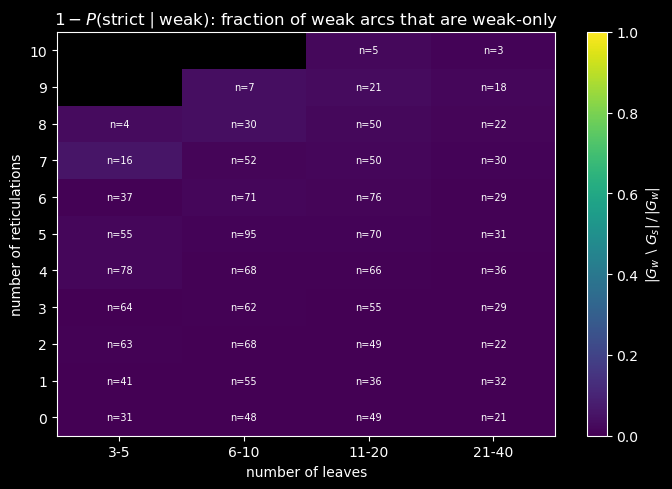

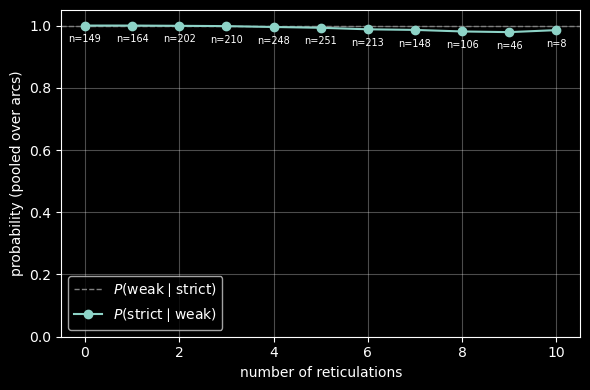

In [21]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

df = pd.read_csv("obj1a_validation.csv")

# --- the proposition: P(weak | strict) = 1, checked, not plotted ---
assert df.inclusion.all(), "inclusion violated"
print(f"P(weak | strict) = 1 in all {len(df)} networks "
      f"({df.n_strict.sum()} strict arcs, all contained in the weak BMG)")

# --- the interesting quantity: P(strict | weak), pooled over arcs ---
def p_strict_given_weak(g):
    return g.n_strict.sum() / g.n_weak.sum()

df["leaf_bin"] = pd.cut(df.n_leaves, [2, 5, 10, 20, 40],
                        labels=["3-5", "6-10", "11-20", "21-40"])

pivot = (df.groupby(["n_retic", "leaf_bin"], observed=True)
           .apply(p_strict_given_weak).unstack("leaf_bin"))
counts = (df.groupby(["n_retic", "leaf_bin"], observed=True)
            .size().unstack("leaf_bin"))

# 1. landscape
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(1 - pivot.values, origin="lower", aspect="auto",
               cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)));   ax.set_yticklabels(pivot.index)
ax.set_xlabel("number of leaves"); ax.set_ylabel("number of reticulations")
ax.set_title(r"$1 - P(\mathrm{strict} \mid \mathrm{weak})$: fraction of weak arcs that are weak-only")
plt.colorbar(im, ax=ax, label=r"$|G_w \setminus G_s|\,/\,|G_w|$")
for r in range(pivot.shape[0]):
    for c in range(pivot.shape[1]):
        if not np.isnan(pivot.values[r, c]):
            ax.text(c, r, f"n={int(counts.values[r, c])}",
                    ha="center", va="center", fontsize=7, color="w")
plt.tight_layout()

# 2. one-dimensional, with P(weak|strict) as the flat reference line
g = df.groupby("n_retic").apply(p_strict_given_weak)
n = df.groupby("n_retic").size()

fig, ax = plt.subplots(figsize=(6, 4))
ax.axhline(1.0, color="grey", ls="--", lw=1, label=r"$P(\mathrm{weak}\mid\mathrm{strict})$")
ax.plot(g.index, g.values, "o-", label=r"$P(\mathrm{strict}\mid\mathrm{weak})$")
for x, y in g.items():
    ax.annotate(f"n={n[x]}", (x, y), textcoords="offset points",
                xytext=(0, -12), ha="center", fontsize=7)
ax.set_xlabel("number of reticulations"); ax.set_ylabel("probability (pooled over arcs)")
ax.set_ylim(0, 1.05); ax.grid(alpha=.3); ax.legend(loc="lower left")
plt.tight_layout()

                      networks  differ  n_strict  n_weak  violations  P(weak|strict)  P(strict|weak) [arcs]  P(any weak-only arc)
leaves reticulations                                                                                                             
2      0                     1       0         2       2           0          1.0000                 1.0000                0.0000
       1                     1       0         2       2           0          1.0000                 1.0000                0.0000
       2                     8       0        16      16           0          1.0000                 1.0000                0.0000
3      0                     8       0        34      34           0          1.0000                 1.0000                0.0000
       1                    24       0        96      96           0          1.0000                 1.0000                0.0000
       2                   268       1      1072    1073           0          1.0000      

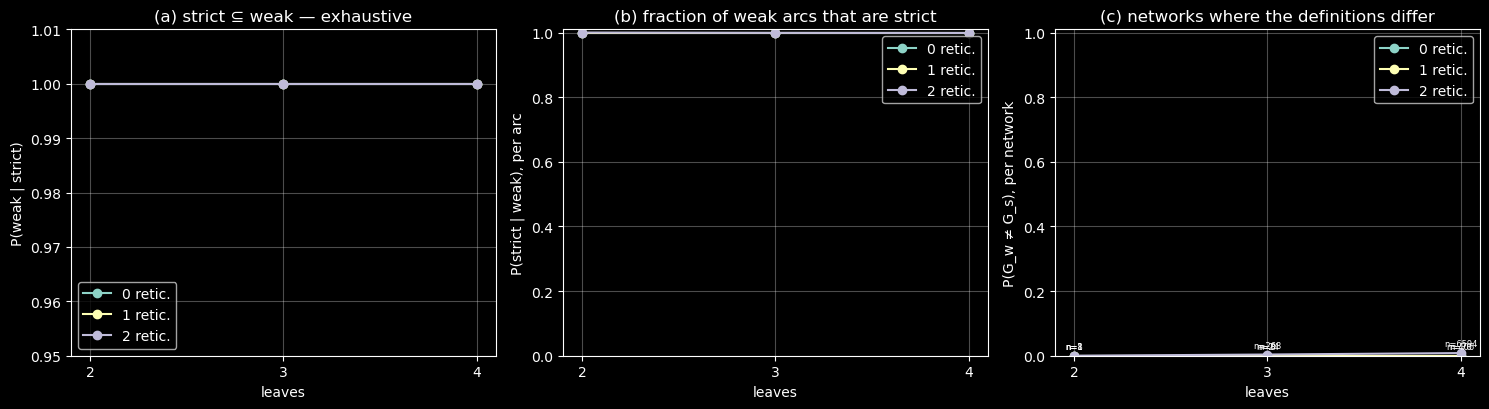

In [23]:
import itertools
from collections import defaultdict
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from bmg_Tony import bmg


# ---------- enumeration primitives ----------

def set_partitions(items):
    if not items:
        yield []
        return
    first, rest = items[0], items[1:]
    for smaller in set_partitions(rest):
        for i in range(len(smaller)):
            yield smaller[:i] + [[first] + smaller[i]] + smaller[i+1:]
        yield [[first]] + smaller


def rooted_trees(leaves):
    if len(leaves) == 1:
        yield leaves[0]
        return
    for blocks in set_partitions(leaves):
        if len(blocks) < 2:
            continue
        for subtrees in itertools.product(*(list(rooted_trees(b)) for b in blocks)):
            yield tuple(subtrees)


def to_digraph(tree):
    G, counter = nx.DiGraph(), itertools.count()
    def build(t, parent):
        if isinstance(t, tuple):
            v = f"i{next(counter)}"
            if parent is not None:
                G.add_edge(parent, v)
            for c in t:
                build(c, v)
            return v
        G.add_edge(parent, t)
    build(tree, None)
    return G


def add_reticulation(G, tag):
    edges = list(G.edges())
    for (a, b), (c, d) in itertools.permutations(edges, 2):
        H = G.copy()
        u, v = f"u{tag}", f"v{tag}"
        H.remove_edges_from([(a, b), (c, d)])
        H.add_edges_from([(a, u), (u, b), (c, v), (v, d), (u, v)])
        if nx.is_directed_acyclic_graph(H):
            yield H


def networks(tree, k):
    level = [to_digraph(tree)]
    for j in range(k):
        level = [H for G in level for H in add_reticulation(G, j)]
    return level


def colourings(leaves, min_colours=2):
    for blocks in set_partitions(leaves):
        if len(blocks) >= min_colours:
            yield {leaf: ci for ci, block in enumerate(blocks) for leaf in block}


def dedup(graphs):
    kept, nm = [], nx.algorithms.isomorphism.categorical_node_match("color", None)
    for G in graphs:
        if not any(nx.is_isomorphic(G, K, node_match=nm) for K in kept):
            kept.append(G)
    return kept


def enumerate_networks(n_max, k_max):
    for n in range(2, n_max + 1):
        leaves = [f"x{i}" for i in range(n)]
        trees = list(rooted_trees(leaves))
        for k in range(k_max + 1):
            nets = dedup([H for t in trees for H in networks(t, k)])
            for H in nets:
                for col in colourings(leaves):
                    N = H.copy()
                    nx.set_node_attributes(N, col, "color")
                    yield n, k, N


# ---------- exhaustive check ----------

N_MAX, K_MAX = 4, 2          # start here; raise to (5, 2) if this finishes quickly

stats = defaultdict(lambda: dict(networks=0, differ=0, n_strict=0, n_weak=0, violations=0))
violations = []

for n, k, N in enumerate_networks(N_MAX, K_MAX):
    Gs = set(bmg(N, "strong").edges())
    Gw = set(bmg(N, "weak").edges())
    s = stats[(n, k)]
    s["networks"] += 1
    s["n_strict"] += len(Gs)
    s["n_weak"] += len(Gw)
    if not Gs <= Gw:
        s["violations"] += 1
        violations.append((n, k, N))
    if Gs != Gw:
        s["differ"] += 1

table = pd.DataFrame.from_dict(stats, orient="index")
table.index.names = ["leaves", "reticulations"]
table["P(weak|strict)"]       = 1 - table.violations / table.networks     # per network, must be 1
table["P(strict|weak) [arcs]"] = table.n_strict / table.n_weak            # pooled over arcs
table["P(any weak-only arc)"] = table.differ / table.networks             # per network
print(table.to_string(float_format="%.4f"))
print(f"\nviolations of strict ⊆ weak: {len(violations)}  "
      f"(exhaustive for ≤{N_MAX} leaves, ≤{K_MAX} reticulations, ≥2 colours)")


# ---------- visualization ----------

t = table.reset_index()
ks = sorted(t.reticulations.unique())

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

# (a) the proposition: P(weak|strict) per class -- flat at 1
ax = axes[0]
for k in ks:
    sub = t[t.reticulations == k]
    ax.plot(sub.leaves, sub["P(weak|strict)"], "o-", label=f"{k} retic.")
ax.set_ylim(0.95, 1.01); ax.set_xlabel("leaves"); ax.set_ylabel("P(weak | strict)")
ax.set_title("(a) strict ⊆ weak — exhaustive"); ax.grid(alpha=.3); ax.legend()

# (b) per arc: P(strict|weak), pooled over all arcs of the class
ax = axes[1]
for k in ks:
    sub = t[t.reticulations == k]
    ax.plot(sub.leaves, sub["P(strict|weak) [arcs]"], "o-", label=f"{k} retic.")
ax.set_ylim(0.0, 1.01); ax.set_xlabel("leaves"); ax.set_ylabel("P(strict | weak), per arc")
ax.set_title("(b) fraction of weak arcs that are strict"); ax.grid(alpha=.3); ax.legend()

# (c) per network: fraction with at least one weak-only arc
ax = axes[2]
for k in ks:
    sub = t[t.reticulations == k]
    ax.plot(sub.leaves, sub["P(any weak-only arc)"], "o-", label=f"{k} retic.")
ax.set_ylim(0.0, 1.01); ax.set_xlabel("leaves"); ax.set_ylabel("P(G_w ≠ G_s), per network")
ax.set_title("(c) networks where the definitions differ"); ax.grid(alpha=.3); ax.legend()

for ax in axes:
    ax.set_xticks(sorted(t.leaves.unique()))
plt.tight_layout()

# annotate class sizes on (c) so nobody reads a thin class as a trend
for k in ks:
    sub = t[t.reticulations == k]
    for _, r in sub.iterrows():
        axes[2].annotate(f"n={int(r.networks)}", (r.leaves, r["P(any weak-only arc)"]),
                         textcoords="offset points", xytext=(0, 5), ha="center", fontsize=6)

if violations:
    n, k, N = violations[0]
    print("first violation:", n, "leaves,", k, "reticulations")
    print(list(N.edges()), nx.get_node_attributes(N, "color"))

weak-only arcs: {('x1', 'x0')}


/Users/alexandermordhorst/anaconda3/envs/AdvancedMethodsinBioinfomartics/lib/python3.14/site-packages/pygraphviz/agraph.py:1403: RuntimeWarning: Warning: 1 is not a known color.

  warnings.warn(b"".join(errors).decode(self.encoding), RuntimeWarning)


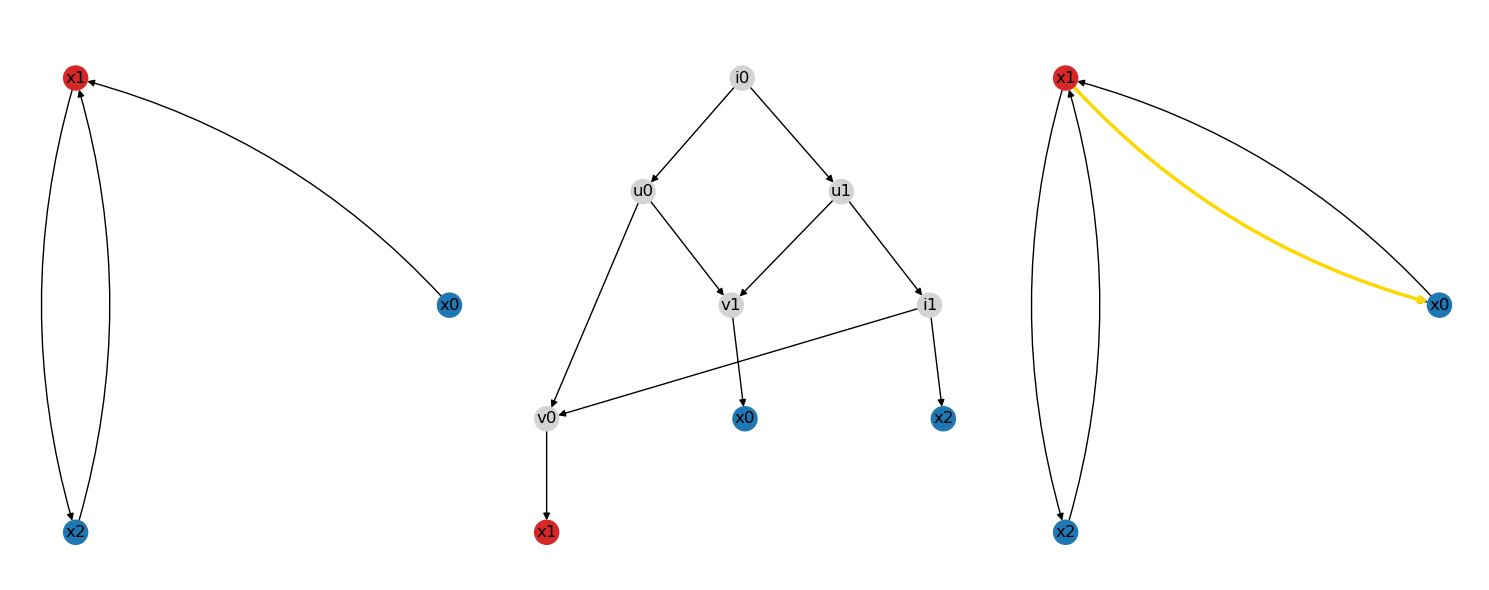

In [26]:
from networkx.drawing.nx_agraph import graphviz_layout

def show_network_and_bmgs(N, title="Network"):
    """Network in the middle, strict BMG left, weak BMG right — same style as the Fig. 2b cell."""
    palette = ["tab:red", "tab:blue", "tab:green", "tab:orange", "tab:purple"]
    leaf_col = {v: palette[c % len(palette)]
                for v, c in nx.get_node_attributes(N, "color").items()}

    fig, axes = plt.subplots(1, 3, figsize=(15, 6))

    # network
    pos = graphviz_layout(N, prog="dot")
    nodes_list = list(N.nodes())
    nodes_colors = [leaf_col.get(v, "lightgrey") for v in nodes_list]
    nx.draw(N, pos, nodelist=nodes_list, node_color=nodes_colors,
            ax=axes[1], with_labels=True, arrows=True)
    axes[1].set_title(title)

    # strict BMG
    Gs = bmg(N, mode="strong")
    pos_b = nx.circular_layout(Gs)
    leaves = list(Gs.nodes())
    leaf_colors = [leaf_col[v] for v in leaves]
    nx.draw(Gs, pos_b, nodelist=leaves, node_color=leaf_colors,
            ax=axes[0], with_labels=True, arrows=True, connectionstyle="arc3,rad=0.15")
    axes[0].set_title(f"strict BMG ({Gs.number_of_edges()} arcs)")

    # weak BMG, weak-only arcs highlighted
    Gw = bmg(N, mode="weak")
    weak_only = set(Gw.edges()) - set(Gs.edges())
    nx.draw(Gw, pos_b, nodelist=leaves, node_color=leaf_colors,
            ax=axes[2], with_labels=True, arrows=True, connectionstyle="arc3,rad=0.15")
    nx.draw_networkx_edges(Gw, pos_b, edgelist=list(weak_only), ax=axes[2],
                           edge_color="gold", width=2.5, arrows=True,
                           connectionstyle="arc3,rad=0.15")
    axes[2].set_title(f"weak BMG ({Gw.number_of_edges()} arcs, {len(weak_only)} weak-only)")

    plt.tight_layout()
    return Gs, Gw


# the minimal witness: 3 leaves, 2 reticulations
witness = next(N for n, k, N in enumerate_networks(3, 2)
               if set(bmg(N, "strong").edges()) != set(bmg(N, "weak").edges()))
Gs, Gw = show_network_and_bmgs(witness, title="minimal witness (3 leaves, 2 reticulations)")
print("weak-only arcs:", set(Gw.edges()) - set(Gs.edges()))

130588 of 130588 strict arcs are weak arcs (100.0%); min over networks: 1.0000, networks below 1: 0


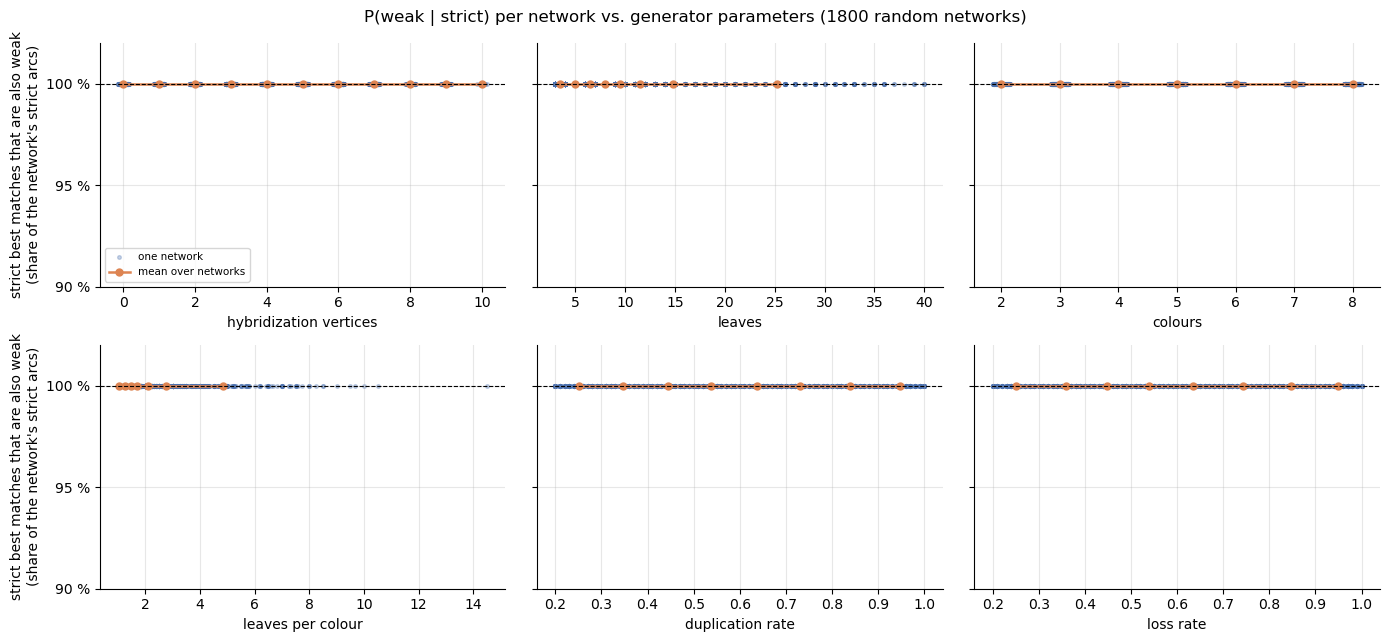

In [10]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
plt.style.use("default")

df = pd.read_csv("obj1a_validation.csv")
df["p_ws"] = df.n_strict_in_weak / df.n_strict          # P(weak | strict), per network
df["leaves_per_color"] = df.n_leaves / df.n_colors

print(f"{df.n_strict_in_weak.sum()} of {df.n_strict.sum()} strict arcs are weak arcs "
      f"({df.n_strict_in_weak.sum() / df.n_strict.sum():.1%}); "
      f"min over networks: {df.p_ws.min():.4f}, networks below 1: {(df.p_ws < 1).sum()}")

params = [
    ("n_retic",          "hybridization vertices", "int"),
    ("n_leaves",         "leaves",                 "bin"),
    ("n_colors",         "colours",                "int"),
    ("leaves_per_color", "leaves per colour",      "bin"),
    ("dupl_rate",        "duplication rate",       "bin"),
    ("loss_rate",        "loss rate",              "bin"),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 6.5), sharey=True, facecolor="white")
rng = np.random.default_rng(0)

for ax, (col, label, kind) in zip(axes.flat, params):
    ax.set_facecolor("white")
    jitter = rng.uniform(-0.15, 0.15, len(df)) if kind == "int" else 0
    ax.scatter(df[col] + jitter, df.p_ws, s=7, alpha=0.3, color="#4C72B0",
               label="one network")

    bins = df[col] if kind == "int" else pd.qcut(df[col], q=8, duplicates="drop")
    g = df.groupby(bins, observed=True)
    ax.plot(g[col].mean(), g.p_ws.mean(), "o-", color="#DD8452", lw=1.8, ms=5,
            label="mean over networks")

    ax.axhline(1.0, color="black", lw=0.8, ls="--")
    ax.set_ylim(0.9, 1.02)
    ax.set_xlabel(label)
    ax.grid(alpha=.3)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)

for ax in axes[:, 0]:
    ax.set_yticks([0.9, 0.95, 1.0])
    ax.set_yticklabels(["90 %", "95 %", "100 %"])
    ax.set_ylabel("strict best matches that are also weak\n(share of the network's strict arcs)")

axes[0, 0].legend(fontsize=7.5, loc="lower left")
fig.suptitle(f"P(weak | strict) per network vs. generator parameters ({len(df)} random networks)")
plt.tight_layout()
plt.savefig("obj1a_weak_given_strict_vs_params.pdf", bbox_inches="tight", facecolor="white")

69% of networks have no weak-only arc at all


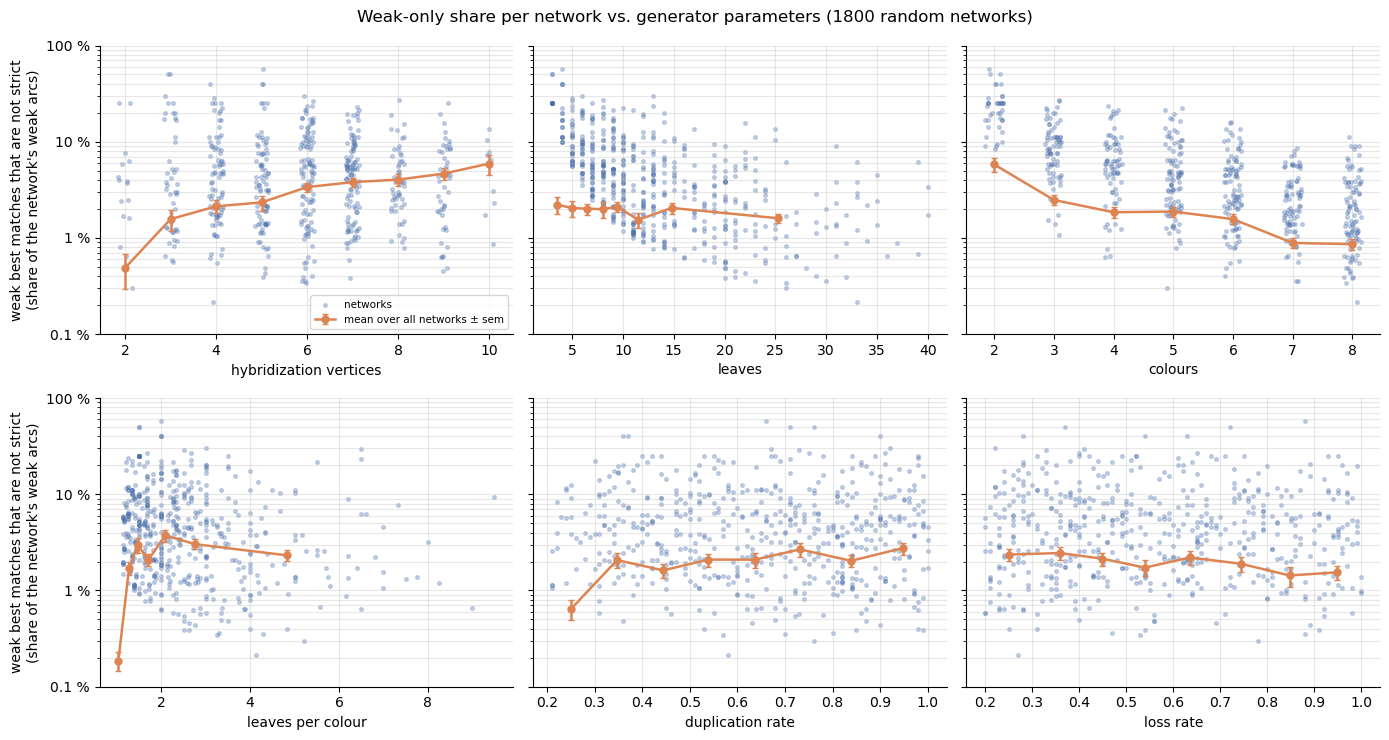

In [9]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
plt.style.use("default")

df = pd.read_csv("obj1a_validation.csv")
df["frac"] = df.n_weak_only / df.n_weak
df["leaves_per_color"] = df.n_leaves / df.n_colors

params = [
    ("n_retic",          "hybridization vertices", "int"),
    ("n_leaves",         "leaves",                 "bin"),
    ("n_colors",         "colours",                "int"),
    ("leaves_per_color", "leaves per colour",      "bin"),
    ("dupl_rate",        "duplication rate",       "bin"),
    ("loss_rate",        "loss rate",              "bin"),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 7.5), sharey=True, facecolor="white")
rng = np.random.default_rng(0)

for ax, (col, label, kind) in zip(axes.flat, params):
    ax.set_facecolor("white")

    # dots: one network each, only those with at least one weak-only arc (log axis)
    nz = df[df.frac > 0]
    jitter = rng.uniform(-0.15, 0.15, len(nz)) if kind == "int" else 0
    ax.scatter(nz[col] + jitter, nz.frac, s=7, alpha=0.3, color="#4C72B0",
               label="networks")

    # curve: mean over ALL networks in the group, zeros included
    bins = df[col] if kind == "int" else pd.qcut(df[col], q=8, duplicates="drop")
    g = df.groupby(bins, observed=True)
    xm = g[col].mean()
    mean_all = g.frac.mean()
    sem = g.frac.sem()
    ok = mean_all > 0
    ax.errorbar(xm[ok], mean_all[ok], yerr=sem[ok], fmt="o-", color="#DD8452",
                lw=1.8, ms=5, capsize=2, label="mean over all networks ± sem")

    ax.set_yscale("log")
    ax.set_ylim(1e-3, 1)
    ax.set_xlabel(label)
    ax.grid(alpha=.3, which="both")
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)

for ax in axes[:, 0]:
    ax.set_yticks([1e-3, 1e-2, 1e-1, 1])
    ax.set_yticklabels(["0.1 %", "1 %", "10 %", "100 %"])
    ax.set_ylabel("weak best matches that are not strict\n(share of the network's weak arcs)")

axes[0, 0].legend(fontsize=7.5, loc="lower right")
fig.suptitle(f"Weak-only share per network vs. generator parameters ({len(df)} random networks)")
plt.tight_layout()
plt.savefig("obj1a_weak_only_vs_params_log.pdf", bbox_inches="tight", facecolor="white")

print(f"{(df.frac == 0).mean():.0%} of networks have no weak-only arc at all")

In [11]:
import itertools
from collections import defaultdict
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from bmg_Tony import bmg
plt.style.use("default")


# ---------- enumeration primitives (no randomness anywhere) ----------

def set_partitions(items):
    if not items:
        yield []
        return
    first, rest = items[0], items[1:]
    for smaller in set_partitions(rest):
        for i in range(len(smaller)):
            yield smaller[:i] + [[first] + smaller[i]] + smaller[i+1:]
        yield [[first]] + smaller


def rooted_trees(leaves):
    if len(leaves) == 1:
        yield leaves[0]
        return
    for blocks in set_partitions(leaves):
        if len(blocks) < 2:
            continue
        for subtrees in itertools.product(*(list(rooted_trees(b)) for b in blocks)):
            yield tuple(subtrees)


def to_digraph(tree):
    G, counter = nx.DiGraph(), itertools.count()
    def build(t, parent):
        if isinstance(t, tuple):
            v = f"i{next(counter)}"
            if parent is not None:
                G.add_edge(parent, v)
            for c in t:
                build(c, v)
            return v
        G.add_edge(parent, t)
    build(tree, None)
    return G


def add_hybrid_vertex(G, tag):
    """Every network obtained from G by subdividing two distinct edges (a,b),(c,d)
    at u,v and adding u -> v.  v becomes a hybridization vertex (in-degree 2)."""
    edges = list(G.edges())
    for (a, b), (c, d) in itertools.permutations(edges, 2):
        H = G.copy()
        u, v = f"u{tag}", f"v{tag}"
        H.remove_edges_from([(a, b), (c, d)])
        H.add_edges_from([(a, u), (u, b), (c, v), (v, d), (u, v)])
        if nx.is_directed_acyclic_graph(H):
            yield H


def networks(tree, k):
    level = [to_digraph(tree)]
    for j in range(k):
        level = [H for G in level for H in add_hybrid_vertex(G, j)]
    return level


def colourings(leaves, min_colours=2):
    for blocks in set_partitions(leaves):
        if len(blocks) >= min_colours:
            yield {leaf: ci for ci, block in enumerate(blocks) for leaf in block}


def dedup(graphs):
    kept, nm = [], nx.algorithms.isomorphism.categorical_node_match("color", None)
    for G in graphs:
        if not any(nx.is_isomorphic(G, K, node_match=nm) for K in kept):
            kept.append(G)
    return kept


def enumerate_networks(n_max, k_max):
    for n in range(2, n_max + 1):
        leaves = [f"x{i}" for i in range(n)]
        trees = list(rooted_trees(leaves))
        for k in range(k_max + 1):
            nets = dedup([H for t in trees for H in networks(t, k)])
            for H in nets:
                for col in colourings(leaves):
                    N = H.copy()
                    nx.set_node_attributes(N, col, "color")
                    yield n, k, N


# ---------- exhaustive check over (leaves, hybrid vertices, colours) ----------

N_MAX, K_MAX = 4, 2

stats = defaultdict(lambda: dict(networks=0, differ=0, n_strict=0, n_weak=0,
                                 n_strict_in_weak=0, n_weak_only=0))
violations, witnesses = [], []

for n, k, N in enumerate_networks(N_MAX, K_MAX):
    c = len(set(nx.get_node_attributes(N, "color").values()))
    Gs = set(bmg(N, "strong").edges())
    Gw = set(bmg(N, "weak").edges())
    s = stats[(n, k, c)]
    s["networks"] += 1
    s["n_strict"] += len(Gs)
    s["n_weak"] += len(Gw)
    s["n_strict_in_weak"] += len(Gs & Gw)
    s["n_weak_only"] += len(Gw - Gs)
    s["differ"] += (Gs != Gw)
    if not Gs <= Gw:
        violations.append((n, k, c, N))
    if Gs != Gw and not witnesses:
        witnesses.append((n, k, c, N))        # first = smallest, since enumeration is by size

table = pd.DataFrame.from_dict(stats, orient="index").sort_index()
table.index.names = ["leaves", "hybrid vertices", "colours"]
table["P(weak|strict)"]  = table.n_strict_in_weak / table.n_strict
table["weak-only share"] = table.n_weak_only / table.n_weak
table["P(G_w ≠ G_s)"]    = table.differ / table.networks
print(table.to_string(float_format="%.4f"))

print(f"\nexhaustive for ≤{N_MAX} leaves, ≤{K_MAX} hybridization vertices, ≥2 colours: "
      f"{table.networks.sum()} coloured networks, {len(violations)} violations of strict ⊆ weak")
if witnesses:
    n, k, c, W = witnesses[0]
    print(f"smallest network with G_w ≠ G_s: {n} leaves, {k} hybridization vertices, {c} colours")
    print(list(W.edges()), nx.get_node_attributes(W, "color"))


# ---------- figure: the two quantities per class ----------

t = table.reset_index()
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), facecolor="white")

for ax, ycol, ylabel in [(axes[0], "P(weak|strict)", "strict arcs that are also weak"),
                         (axes[1], "weak-only share", "weak arcs that are not strict")]:
    ax.set_facecolor("white")
    for k in sorted(t["hybrid vertices"].unique()):
        sub = t[t["hybrid vertices"] == k]
        for c in sorted(sub.colours.unique()):
            s2 = sub[sub.colours == c]
            ax.plot(s2.leaves, s2[ycol], "o-", ms=5, lw=1.4,
                    color=plt.cm.viridis(k / max(1, K_MAX)),
                    alpha=0.5 + 0.5 * c / N_MAX,
                    label=f"{k} hybrid vert., {c} colours")
    ax.set_xlabel("leaves"); ax.set_ylabel(ylabel)
    ax.set_xticks(sorted(t.leaves.unique()))
    ax.grid(alpha=.3)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)

axes[0].set_ylim(0.95, 1.01); axes[0].axhline(1, color="black", lw=0.8, ls="--")
axes[0].set_title("(a)  P(weak | strict) — every class exactly 1")
axes[1].set_ylim(0, max(0.02, 1.2 * t["weak-only share"].max()))
axes[1].set_title("(b)  weak-only share — zero for ≤ 1 hybridization vertex")
axes[1].legend(fontsize=6.5, ncol=2, loc="upper left")
plt.tight_layout()
plt.savefig("obj1a_enumeration.pdf", bbox_inches="tight", facecolor="white")

KeyboardInterrupt: 

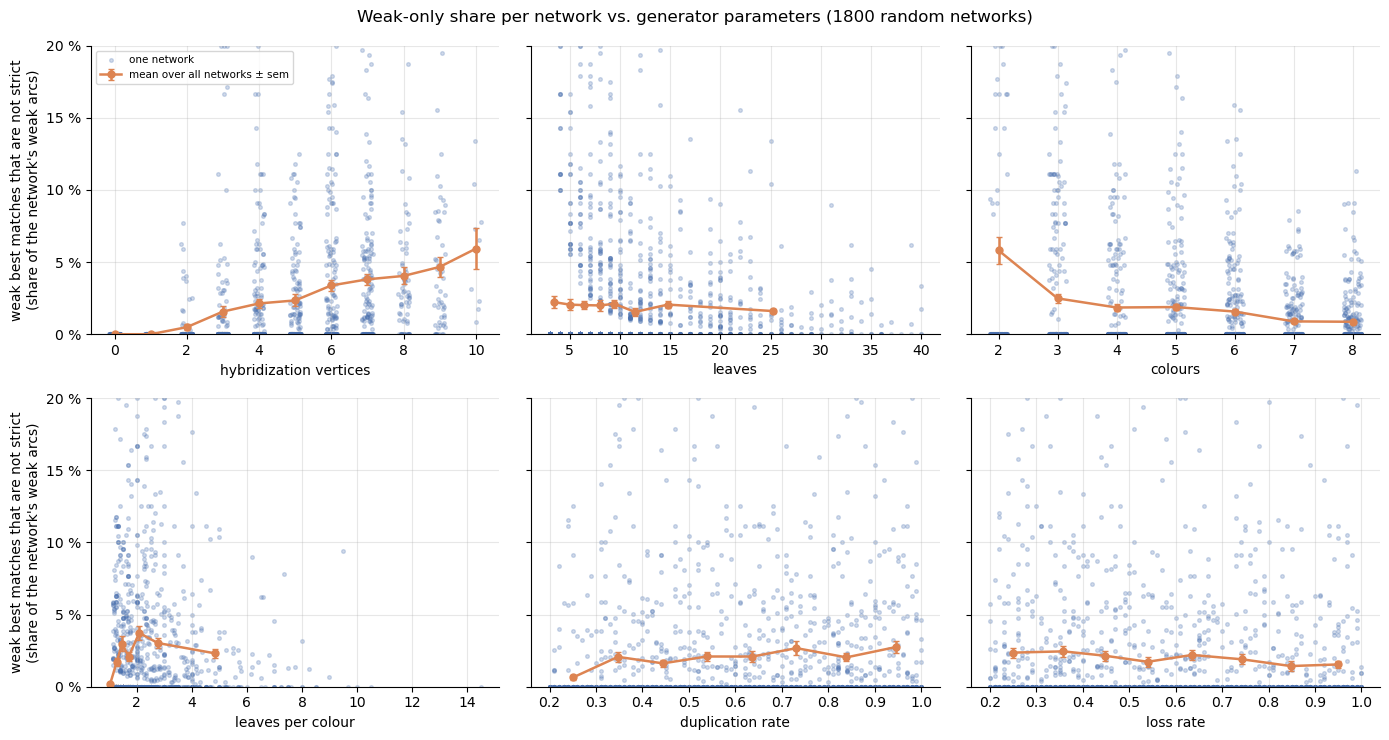

In [14]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
plt.style.use("default")

df = pd.read_csv("obj1a_validation.csv")
df["pct"] = 100 * df.n_weak_only / df.n_weak
df["leaves_per_color"] = df.n_leaves / df.n_colors

params = [
    ("n_retic",          "hybridization vertices", "int"),
    ("n_leaves",         "leaves",                 "bin"),
    ("n_colors",         "colours",                "int"),
    ("leaves_per_color", "leaves per colour",      "bin"),
    ("dupl_rate",        "duplication rate",       "bin"),
    ("loss_rate",        "loss rate",              "bin"),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 7.5), sharey=True, facecolor="white")
rng = np.random.default_rng(0)

for ax, (col, label, kind) in zip(axes.flat, params):
    ax.set_facecolor("white")

    # dots: one network each, zeros included (linear axis, so they sit on the baseline)
    jitter = rng.uniform(-0.15, 0.15, len(df)) if kind == "int" else 0
    ax.scatter(df[col] + jitter, df.pct, s=7, alpha=0.25, color="#4C72B0", label="one network")

    # mean over all networks in the group ± sem
    bins = df[col] if kind == "int" else pd.qcut(df[col], q=8, duplicates="drop")
    g = df.groupby(bins, observed=True)
    ax.errorbar(g[col].mean(), g.pct.mean(), yerr=g.pct.sem(), fmt="o-", color="#DD8452",
                lw=1.8, ms=5, capsize=2, label="mean over all networks ± sem")

    ax.set_ylim(0, 20)
    ax.set_xlabel(label)
    ax.grid(alpha=.3)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)

for ax in axes[:, 0]:
    ax.set_yticks([0, 5, 10, 15, 20])
    ax.set_yticklabels(["0 %", "5 %", "10 %", "15 %", "20 %"])
    ax.set_ylabel("weak best matches that are not strict\n(share of the network's weak arcs)")

axes[0, 0].legend(fontsize=7.5, loc="upper left")
clipped = (df.pct > 20).sum()
fig.suptitle(f"Weak-only share per network vs. generator parameters "
             f"({len(df)} random networks)")
plt.tight_layout()
plt.savefig("obj1a_weak_only_vs_params_lin.pdf", bbox_inches="tight", facecolor="white")